In [5]:
import wrds
import pandas as pd
import os
import time     
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import time

In [6]:
db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [7]:
query = """
SELECT DISTINCT
    c.cik,
    c.conm,
    l.lpermno AS permno,
    m.start,
    m.ending
FROM crsp.msp500list m

JOIN crsp.ccmxpf_linktable l
    ON m.permno = l.lpermno
    AND l.linktype IN ('LU', 'LC')
    AND l.linkprim IN ('P', 'C')

JOIN comp.company c
    ON l.gvkey = c.gvkey

WHERE c.cik IS NOT NULL
    AND m.start <= '2025-12-31'
    AND (m.ending IS NULL OR m.ending >= '2000-01-01')
"""

df = db.raw_sql(query)

bad_keywords = [
    "FUND", "ETF", "TRUST", "PORTFOLIO",
    "SERIES", "INVESTMENT", "SICAV"
]

df = df[~df['conm'].str.upper().str.contains('|'.join(bad_keywords), na=False)]

ciks = df['cik'].dropna().astype(str).str.zfill(10).unique()

cik_df = pd.DataFrame({
    "cik": ciks
})

cik_df.to_csv("sp500_historical_ciks.csv", index=False)

print(f"Saved {len(ciks)} CIKs")

Saved 1046 CIKs


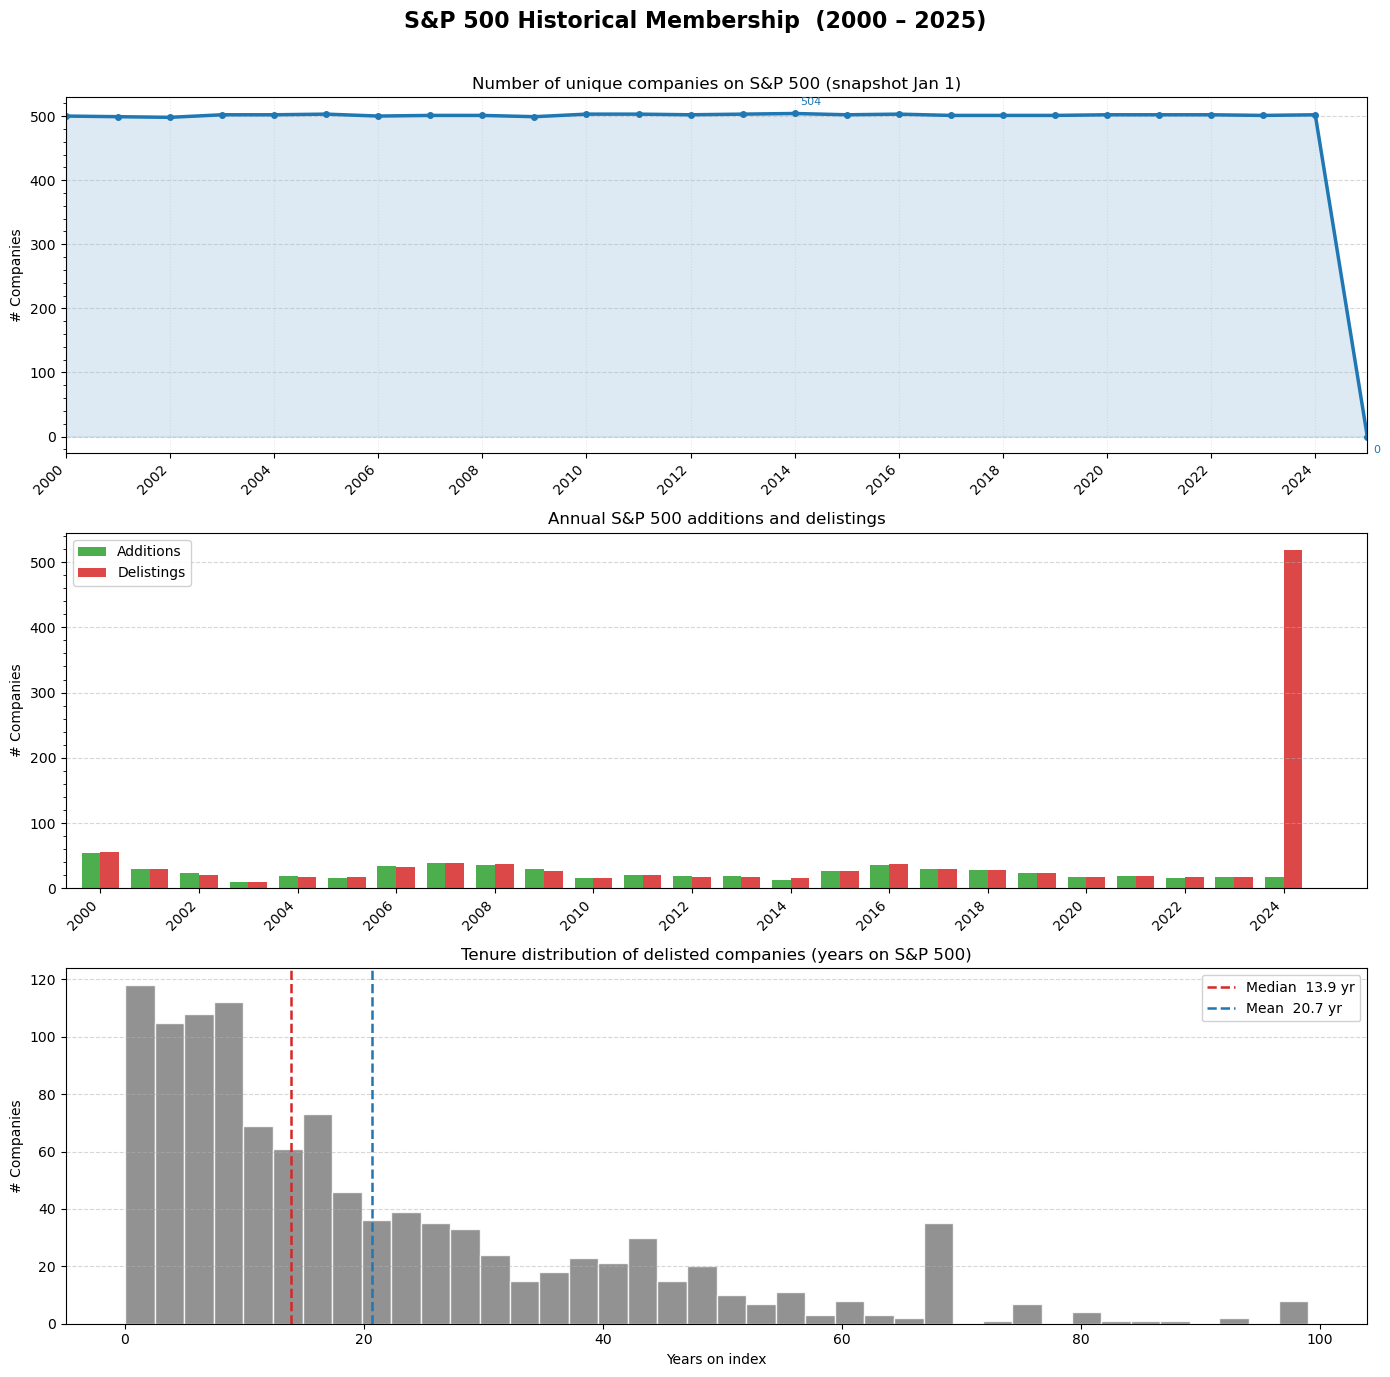

Saved sp500_membership.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Prep ──────────────────────────────────────────────────────────────────────
df_plot = df.copy()
df_plot['start'] = pd.to_datetime(df_plot['start'])
df_plot['ending'] = pd.to_datetime(df_plot['ending'])  # NaT = still listed

YEARS = range(2000, 2026)

# 1. Membership count per year (any overlap with Jan-1 of that year)
counts = []
for y in YEARS:
    snap = pd.Timestamp(f'{y}-01-01')
    n = ((df_plot['start'] <= snap) & (df_plot['ending'].isna() | (df_plot['ending'] >= snap))).sum()
    counts.append(n)

# 2. Additions and deletions per year
df_plot['start_year'] = df_plot['start'].dt.year
df_plot['end_year']   = df_plot['ending'].dt.year  # NaN = still listed

additions  = df_plot.groupby('start_year')['cik'].count().reindex(YEARS, fill_value=0)
delistings = df_plot[df_plot['end_year'].notna()].groupby('end_year')['cik'].count().reindex(YEARS, fill_value=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('S&P 500 Historical Membership  (2000 – 2025)', fontsize=16, fontweight='bold', y=0.98)

BLUE   = '#1f77b4'
GREEN  = '#2ca02c'
RED    = '#d62728'
GREY   = '#7f7f7f'

year_ticks = list(YEARS)

# ── Panel 1: membership count ──────────────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(year_ticks, counts, alpha=0.15, color=BLUE)
ax1.plot(year_ticks, counts, color=BLUE, linewidth=2.5, marker='o', markersize=4)
ax1.set_title('Number of unique companies on S&P 500 (snapshot Jan 1)', fontsize=12)
ax1.set_ylabel('# Companies')
ax1.set_xlim(min(year_ticks), max(year_ticks))
ax1.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.grid(axis='x', linestyle=':', alpha=0.3)
# annotate min/max
ymin_idx = int(np.argmin(counts))
ymax_idx = int(np.argmax(counts))
ax1.annotate(f'{counts[ymax_idx]}', xy=(year_ticks[ymax_idx], counts[ymax_idx]),
             xytext=(4, 6), textcoords='offset points', fontsize=8, color=BLUE)
ax1.annotate(f'{counts[ymin_idx]}', xy=(year_ticks[ymin_idx], counts[ymin_idx]),
             xytext=(4, -12), textcoords='offset points', fontsize=8, color=BLUE)

# ── Panel 2: additions vs removals bar chart ───────────────────────────────
ax2 = axes[1]
x = np.array(year_ticks)
w = 0.38
ax2.bar(x - w/2, additions.values,  width=w, label='Additions',  color=GREEN, alpha=0.85)
ax2.bar(x + w/2, delistings.values, width=w, label='Delistings', color=RED,   alpha=0.85)
ax2.set_title('Annual S&P 500 additions and delistings', fontsize=12)
ax2.set_ylabel('# Companies')
ax2.set_xlim(min(year_ticks) - 0.7, max(year_ticks) + 0.7)
ax2.legend(framealpha=0.9)
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# ── Panel 3: tenure distribution for delisted companies ───────────────────
ax3 = axes[2]
delisted = df_plot[df_plot['ending'].notna()].copy()
delisted['tenure_years'] = (delisted['ending'] - delisted['start']).dt.days / 365.25
# clip negative (data artefacts) and very long tenures for readability
tenure = delisted['tenure_years'].clip(lower=0)

ax3.hist(tenure, bins=40, color=GREY, edgecolor='white', alpha=0.85)
ax3.axvline(tenure.median(), color=RED,  linestyle='--', linewidth=1.8,
            label=f'Median  {tenure.median():.1f} yr')
ax3.axvline(tenure.mean(),   color=BLUE, linestyle='--', linewidth=1.8,
            label=f'Mean  {tenure.mean():.1f} yr')
ax3.set_title('Tenure distribution of delisted companies (years on S&P 500)', fontsize=12)
ax3.set_xlabel('Years on index')
ax3.set_ylabel('# Companies')
ax3.legend(framealpha=0.9)
ax3.grid(axis='y', linestyle='--', alpha=0.5)

# ── Shared x-axis formatting ───────────────────────────────────────────────
for ax in (ax1, ax2):
    ax.set_xticks(year_ticks[::2])
    ax.set_xticklabels([str(y) for y in year_ticks[::2]], rotation=45, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('sp500_membership.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sp500_membership.png')
